# Random Positioning Machine Simulator - Python Notebook Version

This notebook is a Python/Jupyter companion to the HTML Random Positioning Machine simulator. It keeps the same scientific goals while using Python tools instead of browser/HTML code.

It models a two-axis RPM holding a square agar plate with Arabidopsis seedlings, computes sample-frame gravity over time, compares static/random/microgravity/biased partial-gravity runs, checks physical sample-point accelerations across the plate, and exports figures/data for review or microcontroller planning.

**Important:** this file is separate from `index.html`; running or editing it will not affect the HTML simulator.

## What This Notebook Includes

- Static, random-walk, microgravity-optimized, and biased partial-gravity scenarios
- Outer and inner gimbal rotations with velocity and acceleration limits
- Optional centrifugal and Coriolis acceleration terms
- Plate, inner rotator, and outer rotator dimensions in metric units
- Center, corner, grid, or custom sample-point acceleration analysis
- Moving-window gravity analysis over biologically meaningful time scales
- Target validation for zero-g, Moon, Mars, or arbitrary target gravity levels
- 3D plots of the gimbal, plate, gravity vectors, sample paths, and sampled gravity sphere
- PDF report export on normal letter-size pages with vector-style Matplotlib plots
- CSV command schedule and Arduino-style pseudocode export for machine builders

In [1]:
# Core scientific stack. These packages are common in Anaconda and most Jupyter installs.
import math
import time
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401; activates 3D projections

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False

G = 9.80665
DEG = math.pi / 180.0
WORLD_G = np.array([0.0, 0.0, -1.0])
OUTER_AXIS_WORLD = np.array([0.0, 1.0, 0.0])
INNER_AXIS_OUTER = np.array([1.0, 0.0, 0.0])
TARGET_DIR = np.array([0.0, 0.0, -1.0])
RNG = np.random.default_rng(42)

plt.rcParams.update({
    "figure.figsize": (8.5, 5.2),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

In [2]:
@dataclass
class RPMConfig:
    """All model parameters for one RPM experiment.

    Units are metric unless stated otherwise. Angles entered in degrees are converted
    to radians internally by the simulation functions.
    """
    scenario: str = "micro"  # static, random, micro, biased
    duration_days: float = 0.01
    dt: float = 0.25

    random_turn_strength_deg_s: float = 7.0
    max_angular_velocity_deg_s: float = 40.0
    max_angular_acceleration_deg_s2: float = 8.0
    rotation_limit_deg: float = 180.0

    bias_strength: float = 3.0
    target_g: float = 0.0

    plate_side_mm: float = 90.0
    inner_rotator_diameter_mm: float = 160.0
    outer_rotator_diameter_mm: float = 260.0
    sample_offset_mm: float = 0.0

    include_centrifugal: bool = True
    include_coriolis: bool = False

    # Long biological experiments can be many days. Fast runs coarsen the output
    # cadence so a notebook cell finishes quickly while preserving the requested duration.
    max_fast_steps: int = 25000

    # Builder / microcontroller planning parameters.
    control_hz: float = 20.0
    steps_per_rev: int = 200
    gear_ratio: float = 20.0
    encoder_counts: int = 4096
    backlash_deg: float = 0.2
    angle_noise_deg: float = 0.05
    timing_jitter_ms: float = 2.0

    @property
    def duration_s(self) -> float:
        return float(self.duration_days) * 24.0 * 3600.0

    def copy(self, **updates):
        return replace(self, **updates)


def preset_config(name: str) -> RPMConfig:
    """Convenience presets for common demonstrations."""
    key = name.lower().strip()
    if key in {"zero", "0g", "micro", "microgravity"}:
        return RPMConfig(scenario="micro", target_g=0.0, bias_strength=0.0,
                         random_turn_strength_deg_s=8.0,
                         max_angular_velocity_deg_s=40.0,
                         max_angular_acceleration_deg_s2=6.0)
    if key in {"moon", "lunar"}:
        return RPMConfig(scenario="biased", target_g=0.166, bias_strength=5.0)
    if key == "mars":
        return RPMConfig(scenario="biased", target_g=0.38, bias_strength=5.0)
    if key in {"static", "control"}:
        return RPMConfig(scenario="static", target_g=1.0, bias_strength=0.0)
    raise ValueError(f"Unknown preset: {name}")

In [3]:
def clamp(value, lo, hi):
    return max(lo, min(hi, value))


def wrap_angle_rad(angle):
    return (angle + math.pi) % (2.0 * math.pi) - math.pi


def rotation_matrix_axis_angle(axis, angle):
    """Rodrigues rotation matrix for a unit axis and angle in radians."""
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)
    x, y, z = axis
    c = math.cos(angle)
    s = math.sin(angle)
    C = 1.0 - c
    return np.array([
        [c + x*x*C, x*y*C - z*s, x*z*C + y*s],
        [y*x*C + z*s, c + y*y*C, y*z*C - x*s],
        [z*x*C - y*s, z*y*C + x*s, c + z*z*C],
    ])


def sample_rotation_matrix(theta_outer, theta_inner):
    """Return sample-to-world rotation for a two-axis gimbal.

    The outer ring rotates about a horizontal world Y axis. The inner ring rotates about
    the outer ring's local X axis, so both RPM axes change the sample-frame gravity vector.
    """
    r_outer = rotation_matrix_axis_angle(OUTER_AXIS_WORLD, theta_outer)
    inner_axis_world = r_outer @ INNER_AXIS_OUTER
    r_inner_world = rotation_matrix_axis_angle(inner_axis_world, theta_inner)
    return r_inner_world @ r_outer


def gravity_for_angles(theta_outer, theta_inner):
    """World gravity expressed in sample coordinates, in units of g."""
    r_sample_to_world = sample_rotation_matrix(theta_outer, theta_inner)
    return r_sample_to_world.T @ WORLD_G


def random_unit_vector(rng=RNG):
    v = rng.normal(size=3)
    return v / np.linalg.norm(v)

In [4]:
@dataclass
class RPMState:
    theta_outer: float = 0.0
    theta_inner: float = 0.0
    omega_outer: float = 0.0
    omega_inner: float = 0.0
    prev_omega_outer: float = 0.0
    prev_omega_inner: float = 0.0
    avg_g: np.ndarray = None
    steps: int = 0

    def __post_init__(self):
        if self.avg_g is None:
            self.avg_g = np.zeros(3)


def angular_vector_sample(state: RPMState):
    """Approximate angular velocity vector in sample coordinates."""
    r = sample_rotation_matrix(state.theta_outer, state.theta_inner)
    r_outer = rotation_matrix_axis_angle(OUTER_AXIS_WORLD, state.theta_outer)
    inner_axis_world = r_outer @ INNER_AXIS_OUTER
    omega_world = state.omega_outer * OUTER_AXIS_WORLD + state.omega_inner * inner_axis_world
    return r.T @ omega_world


def local_acceleration_at(point_sample_m, state: RPMState, cfg: RPMConfig, dt: float):
    """Total acceleration at a plate point, in sample coordinates and units of g.

    Gravity is always 1 g instantaneously. Centrifugal and Coriolis-like terms
    can introduce small plate-position-dependent differences.
    """
    g_sample = gravity_for_angles(state.theta_outer, state.theta_inner)
    total = np.array(g_sample, dtype=float)
    omega = angular_vector_sample(state)
    alpha = np.array([
        (state.omega_inner - state.prev_omega_inner) / max(dt, 1e-9),
        0.0,
        (state.omega_outer - state.prev_omega_outer) / max(dt, 1e-9),
    ])
    r = np.asarray(point_sample_m, dtype=float)

    if cfg.include_centrifugal:
        total += -np.cross(omega, np.cross(omega, r)) / G
    if cfg.include_coriolis:
        # For a rigidly mounted sample point, relative velocity is near zero.
        # This term is kept as an optional placeholder for moving samples/fluids.
        v_relative = np.zeros(3)
        total += -2.0 * np.cross(omega, v_relative) / G
    return total


def candidate_step(state: RPMState, cfg: RPMConfig, dt: float, rng=RNG):
    """Generate one smooth random-walk candidate step.

    Velocity targets persist for enough time to avoid frame-to-frame jitter. The
    acceleration cap then limits how fast the motors can reach those targets.
    """
    max_w = cfg.max_angular_velocity_deg_s * DEG
    max_a = cfg.max_angular_acceleration_deg_s2 * DEG
    turn_strength = cfg.random_turn_strength_deg_s * DEG

    target_outer = state.omega_outer + rng.normal(0.0, turn_strength * math.sqrt(dt))
    target_inner = state.omega_inner + rng.normal(0.0, turn_strength * math.sqrt(dt))
    speed = math.hypot(target_outer, target_inner)
    if speed > max_w:
        target_outer *= max_w / speed
        target_inner *= max_w / speed

    dw_outer = clamp(target_outer - state.omega_outer, -max_a * dt, max_a * dt)
    dw_inner = clamp(target_inner - state.omega_inner, -max_a * dt, max_a * dt)

    next_state = replace(state)
    next_state.prev_omega_outer = state.omega_outer
    next_state.prev_omega_inner = state.omega_inner
    next_state.omega_outer = clamp(state.omega_outer + dw_outer, -max_w, max_w)
    next_state.omega_inner = clamp(state.omega_inner + dw_inner, -max_w, max_w)
    next_state.theta_outer = wrap_angle_rad(state.theta_outer + next_state.omega_outer * dt)
    next_state.theta_inner = wrap_angle_rad(state.theta_inner + next_state.omega_inner * dt)

    if cfg.rotation_limit_deg < 180.0:
        lim = cfg.rotation_limit_deg * DEG
        next_state.theta_outer = clamp(next_state.theta_outer, -lim, lim)
        next_state.theta_inner = clamp(next_state.theta_inner, -lim, lim)
    return next_state


def choose_biased_candidate(state: RPMState, cfg: RPMConfig, dt: float, rng=RNG, n_candidates=12):
    """Bias candidate steps toward a requested nonzero average gravity vector."""
    target = TARGET_DIR * cfg.target_g
    best_state = None
    best_score = float("inf")
    for _ in range(n_candidates):
        cand = candidate_step(state, cfg, dt, rng)
        g = gravity_for_angles(cand.theta_outer, cand.theta_inner)
        prospective_avg = (state.avg_g * state.steps + g) / (state.steps + 1)
        score = np.linalg.norm(prospective_avg - target)
        score -= cfg.bias_strength * 0.002 * np.dot(g, target)
        if score < best_score:
            best_state = cand
            best_score = score
    return best_state


def choose_microgravity_candidate(state: RPMState, cfg: RPMConfig, dt: float, rng=RNG, n_candidates=16):
    """Bias random motion toward cancelling the current cumulative gravity average."""
    best_state = None
    best_score = float("inf")
    for _ in range(n_candidates):
        cand = candidate_step(state, cfg, dt, rng)
        g = gravity_for_angles(cand.theta_outer, cand.theta_inner)
        prospective_avg = (state.avg_g * state.steps + g) / (state.steps + 1)
        coverage_bonus = 0.01 * np.dot(g, random_unit_vector(rng))
        score = np.linalg.norm(prospective_avg) - coverage_bonus
        if score < best_score:
            best_state = cand
            best_score = score
    return best_state


def integrate_step(state: RPMState, cfg: RPMConfig, dt: float, rng=RNG):
    if cfg.scenario == "static":
        next_state = replace(state)
        next_state.prev_omega_outer = state.omega_outer
        next_state.prev_omega_inner = state.omega_inner
        next_state.omega_outer = 0.0
        next_state.omega_inner = 0.0
    elif cfg.scenario == "biased":
        next_state = choose_biased_candidate(state, cfg, dt, rng)
    elif cfg.scenario in {"micro", "zero", "0g"}:
        next_state = choose_microgravity_candidate(state, cfg, dt, rng)
    else:
        next_state = candidate_step(state, cfg, dt, rng)

    g = gravity_for_angles(next_state.theta_outer, next_state.theta_inner)
    next_state.steps = state.steps + 1
    next_state.avg_g = (state.avg_g * state.steps + g) / next_state.steps
    return next_state, g

In [5]:
def run_experiment(cfg: RPMConfig, seed=42, fast=True, progress=True):
    """Run a complete RPM experiment and return a pandas DataFrame plus metadata."""
    rng = np.random.default_rng(seed)
    dt = float(cfg.dt)
    if fast and cfg.duration_s / dt > cfg.max_fast_steps:
        dt = cfg.duration_s / cfg.max_fast_steps
    n_steps = max(1, int(math.ceil(cfg.duration_s / dt)))

    state = RPMState()
    rows = []
    heat_bins = np.zeros((36, 18), dtype=int)
    t0 = time.time()

    for i in range(n_steps):
        state, g_sample = integrate_step(state, cfg, dt, rng)
        center_acc = local_acceleration_at([0, 0, cfg.sample_offset_mm / 1000.0], state, cfg, dt)
        omega_mag = math.hypot(state.omega_outer, state.omega_inner)
        alpha_outer = (state.omega_outer - state.prev_omega_outer) / max(dt, 1e-9)
        alpha_inner = (state.omega_inner - state.prev_omega_inner) / max(dt, 1e-9)
        alpha_mag = math.hypot(alpha_outer, alpha_inner)

        lon = math.atan2(g_sample[1], g_sample[0])
        lat = math.asin(clamp(g_sample[2] / max(np.linalg.norm(g_sample), 1e-12), -1, 1))
        lon_i = int(((lon + math.pi) / (2 * math.pi)) * heat_bins.shape[0]) % heat_bins.shape[0]
        lat_i = int(((lat + math.pi/2) / math.pi) * heat_bins.shape[1])
        lat_i = max(0, min(heat_bins.shape[1] - 1, lat_i))
        heat_bins[lon_i, lat_i] += 1

        rows.append({
            "time_s": i * dt,
            "time_hr": i * dt / 3600.0,
            "outer_angle_deg": state.theta_outer / DEG,
            "inner_angle_deg": state.theta_inner / DEG,
            "gx": g_sample[0], "gy": g_sample[1], "gz": g_sample[2],
            "g_mag": float(np.linalg.norm(g_sample)),
            "avg_gx": state.avg_g[0], "avg_gy": state.avg_g[1], "avg_gz": state.avg_g[2],
            "avg_g_mag": float(np.linalg.norm(state.avg_g)),
            "omega_outer_deg_s": state.omega_outer / DEG,
            "omega_inner_deg_s": state.omega_inner / DEG,
            "omega_mag_deg_s": omega_mag / DEG,
            "alpha_outer_deg_s2": alpha_outer / DEG,
            "alpha_inner_deg_s2": alpha_inner / DEG,
            "alpha_mag_deg_s2": alpha_mag / DEG,
            "center_total_accel_g": float(np.linalg.norm(center_acc)),
            "extra_accel_g": float(abs(np.linalg.norm(center_acc) - 1.0)),
        })

        if progress and n_steps > 5000 and i % max(1, n_steps // 10) == 0:
            print(f"{100*i/n_steps:5.1f}% complete")

    df = pd.DataFrame(rows)
    meta = {
        "dt_used_s": dt,
        "n_steps": n_steps,
        "runtime_s": time.time() - t0,
        "heat_bins": heat_bins,
        "config": cfg,
    }
    return df, meta

In [6]:
def target_vector(cfg: RPMConfig):
    return TARGET_DIR * float(cfg.target_g)


def moving_average_worst(df, window_s, component_cols=("gx", "gy", "gz")):
    if len(df) < 2:
        return np.nan, np.array([np.nan, np.nan, np.nan])
    dt = float(np.median(np.diff(df["time_s"])))
    win = max(1, int(round(window_s / max(dt, 1e-9))))
    roll = df[list(component_cols)].rolling(win, min_periods=1).mean()
    mags = np.linalg.norm(roll.values, axis=1)
    idx = int(np.nanargmax(mags))
    return float(mags[idx]), roll.iloc[idx].values


def time_to_within(df, target_mag, tolerance_fraction):
    target = max(abs(target_mag), 1e-9)
    error = np.abs(df["avg_g_mag"].values - target) / target
    ok = np.where(error <= tolerance_fraction)[0]
    return float(df["time_s"].iloc[ok[0]]) if len(ok) else np.nan


def orientation_uniformity(meta):
    heat = meta["heat_bins"].astype(float)
    used = heat[heat > 0]
    coverage = float((heat > 0).sum() / heat.size)
    cv = float(used.std() / used.mean()) if len(used) else np.nan
    return {"sphere_bin_coverage_fraction": coverage, "occupied_bin_cv": cv}


def target_validation(df, meta):
    cfg = meta["config"]
    target = target_vector(cfg)
    avg_vec = df[["avg_gx", "avg_gy", "avg_gz"]].iloc[-1].values
    instant = df[["gx", "gy", "gz"]].values
    running = df[["avg_gx", "avg_gy", "avg_gz"]].values
    error_vec = running - target
    rms_error = float(np.sqrt(np.mean(np.sum(error_vec**2, axis=1))))
    final_mag = float(np.linalg.norm(avg_vec))
    target_mag = float(np.linalg.norm(target))
    percent_error = 100.0 * abs(final_mag - target_mag) / max(target_mag, 1e-9)

    windows = {
        "10 s": 10,
        "1 min": 60,
        "10 min": 600,
        "1 hr": 3600,
        "full": max(float(df["time_s"].iloc[-1]), 1.0),
    }
    window_rows = []
    for label, seconds in windows.items():
        mag, vec = moving_average_worst(df, seconds)
        window_rows.append({"window": label, "worst_avg_g_mag": mag,
                            "x": vec[0], "y": vec[1], "z": vec[2]})

    drift = float(np.linalg.norm(running[-1] - running[len(running)//2])) if len(running) > 2 else np.nan
    uniformity = orientation_uniformity(meta)
    summary = {
        "final_average_g_magnitude": final_mag,
        "final_average_vector_x": avg_vec[0],
        "final_average_vector_y": avg_vec[1],
        "final_average_vector_z": avg_vec[2],
        "target_g_magnitude": target_mag,
        "percent_error_from_target": percent_error,
        "rms_vector_error_g": rms_error,
        "time_to_within_10_percent_s": time_to_within(df, target_mag, 0.10) if target_mag > 0 else np.nan,
        "time_to_within_5_percent_s": time_to_within(df, target_mag, 0.05) if target_mag > 0 else np.nan,
        "time_to_within_1_percent_s": time_to_within(df, target_mag, 0.01) if target_mag > 0 else np.nan,
        "mid_to_final_avg_vector_drift_g": drift,
        **uniformity,
    }
    return pd.Series(summary), pd.DataFrame(window_rows)


def selected_sample_points(cfg: RPMConfig, mode="grid", custom_points_mm=None, grid_n=5):
    half = cfg.plate_side_mm / 2.0
    if mode == "center":
        pts = [("center", 0.0, 0.0)]
    elif mode == "corners":
        pts = [("corner_NE", half, half), ("corner_NW", -half, half),
               ("corner_SW", -half, -half), ("corner_SE", half, -half), ("center", 0.0, 0.0)]
    elif mode == "custom" and custom_points_mm:
        pts = [(f"custom_{i+1}", x, y) for i, (x, y) in enumerate(custom_points_mm)]
    else:
        coords = np.linspace(-half, half, grid_n)
        pts = [(f"grid_{ix}_{iy}", x, y) for ix, x in enumerate(coords) for iy, y in enumerate(coords)]
    return pd.DataFrame(pts, columns=["point", "x_mm", "y_mm"])


def sample_point_analysis(df, meta, mode="grid", custom_points_mm=None, grid_n=5):
    cfg = meta["config"]
    pts = selected_sample_points(cfg, mode, custom_points_mm, grid_n)
    dt = meta["dt_used_s"]
    # Use a representative subset for long runs to keep analysis quick.
    subset = df.iloc[np.linspace(0, len(df)-1, min(len(df), 2000)).astype(int)]
    records = []
    for _, p in pts.iterrows():
        mags = []
        cent_terms = []
        for _, row in subset.iterrows():
            state = RPMState(theta_outer=row.outer_angle_deg*DEG, theta_inner=row.inner_angle_deg*DEG,
                             omega_outer=row.omega_outer_deg_s*DEG, omega_inner=row.omega_inner_deg_s*DEG)
            r = np.array([p.x_mm/1000.0, p.y_mm/1000.0, cfg.sample_offset_mm/1000.0])
            acc = local_acceleration_at(r, state, cfg, dt)
            mags.append(np.linalg.norm(acc))
            omega = angular_vector_sample(state)
            cent = -np.cross(omega, np.cross(omega, r)) / G
            cent_terms.append(np.linalg.norm(cent))
        records.append({
            "point": p.point,
            "x_mm": p.x_mm,
            "y_mm": p.y_mm,
            "mean_accel_g": float(np.mean(mags)),
            "min_accel_g": float(np.min(mags)),
            "max_accel_g": float(np.max(mags)),
            "range_g": float(np.max(mags) - np.min(mags)),
            "worst_centrifugal_g": float(np.max(cent_terms)),
        })
    out = pd.DataFrame(records)
    center_mean = out.loc[out["point"].eq("center"), "mean_accel_g"]
    center = float(center_mean.iloc[0]) if len(center_mean) else float(out["mean_accel_g"].mean())
    summary = pd.Series({
        "selected_points": len(out),
        "center_acceleration_g": center,
        "selected_point_min_g": float(out["mean_accel_g"].min()),
        "selected_point_max_g": float(out["mean_accel_g"].max()),
        "selected_point_mean_g": float(out["mean_accel_g"].mean()),
        "acceleration_range_across_points_g": float(out["mean_accel_g"].max() - out["mean_accel_g"].min()),
        "corner_or_custom_vs_center_difference_g": float(np.max(np.abs(out["mean_accel_g"] - center))),
        "worst_case_centrifugal_g": float(out["worst_centrifugal_g"].max()),
        "gradient_significance": "negligible (<0.001 g)" if float(out["mean_accel_g"].max() - out["mean_accel_g"].min()) < 0.001 else "measureable",
    })
    return out, summary


def builder_metrics(cfg: RPMConfig):
    motor_steps_per_output_rev = cfg.steps_per_rev * cfg.gear_ratio
    steps_per_degree = motor_steps_per_output_rev / 360.0
    encoder_counts_per_degree = cfg.encoder_counts / 360.0
    max_step_rate = steps_per_degree * cfg.max_angular_velocity_deg_s
    max_step_accel = steps_per_degree * cfg.max_angular_acceleration_deg_s2
    return pd.Series({
        "control_loop_hz": cfg.control_hz,
        "control_loop_period_ms": 1000.0 / cfg.control_hz,
        "steps_per_output_degree": steps_per_degree,
        "encoder_counts_per_degree": encoder_counts_per_degree,
        "max_commanded_speed_deg_s": cfg.max_angular_velocity_deg_s,
        "max_motor_step_rate_steps_s": max_step_rate,
        "max_motor_step_accel_steps_s2": max_step_accel,
        "backlash_allowance_deg": cfg.backlash_deg,
        "angle_noise_deg": cfg.angle_noise_deg,
        "timing_jitter_ms": cfg.timing_jitter_ms,
        "inner_rotator_diameter_mm": cfg.inner_rotator_diameter_mm,
        "outer_rotator_diameter_mm": cfg.outer_rotator_diameter_mm,
    })

In [7]:
def plot_time_series(df, cfg=None):
    fig, axes = plt.subplots(5, 1, figsize=(8.5, 10.5), sharex=True, constrained_layout=True)
    axes[0].plot(df.time_hr, df.gx, label="gx")
    axes[0].plot(df.time_hr, df.gy, label="gy")
    axes[0].plot(df.time_hr, df.gz, label="gz")
    axes[0].set_ylabel("instantaneous g")
    axes[0].legend(ncol=3)

    axes[1].plot(df.time_hr, df.avg_g_mag, color="black")
    if cfg is not None:
        axes[1].axhline(cfg.target_g, color="tab:red", ls="--", label="target")
        axes[1].legend()
    axes[1].set_ylabel("running avg |g|")

    axes[2].plot(df.time_hr, df.center_total_accel_g, color="tab:purple")
    axes[2].set_ylabel("center total |a| g")

    axes[3].plot(df.time_hr, df.omega_outer_deg_s, label="outer")
    axes[3].plot(df.time_hr, df.omega_inner_deg_s, label="inner")
    axes[3].set_ylabel("deg/s")
    axes[3].legend(ncol=2)

    axes[4].plot(df.time_hr, df.alpha_outer_deg_s2, label="outer")
    axes[4].plot(df.time_hr, df.alpha_inner_deg_s2, label="inner")
    axes[4].set_ylabel("deg/s²")
    axes[4].set_xlabel("time (hours)")
    axes[4].legend(ncol=2)
    return fig


def plot_gravity_sphere(df, meta=None, stride=None):
    if stride is None:
        stride = max(1, len(df)//2500)
    pts = df[["gx", "gy", "gz"]].iloc[::stride].values
    fig = plt.figure(figsize=(8.5, 7.0), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")
    u = np.linspace(0, 2*np.pi, 48)
    v = np.linspace(0, np.pi, 24)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(x, y, z, color="0.75", linewidth=0.35, alpha=0.5)
    ax.plot(pts[:,0], pts[:,1], pts[:,2], color="tab:green", lw=0.8, alpha=0.75, label="sample-frame gravity path")
    ax.scatter(pts[:1,0], pts[:1,1], pts[:1,2], color="tab:blue", s=40, label="start")
    ax.scatter(pts[-1:,0], pts[-1:,1], pts[-1:,2], color="tab:red", s=40, label="end")
    ax.quiver(0,0,0, df.avg_gx.iloc[-1], df.avg_gy.iloc[-1], df.avg_gz.iloc[-1], color="black", linewidth=2, label="final average")
    ax.set(xlim=(-1,1), ylim=(-1,1), zlim=(-1,1), xlabel="sample X", ylabel="sample Y", zlabel="sample Z")
    ax.set_box_aspect((1,1,1))
    ax.legend(loc="upper left")
    return fig


def plot_gimbal_3d(df, cfg: RPMConfig, index=-1):
    row = df.iloc[index]
    r = sample_rotation_matrix(row.outer_angle_deg*DEG, row.inner_angle_deg*DEG)
    plate_half = cfg.plate_side_mm / 2000.0
    corners = np.array([[-plate_half,-plate_half,0], [plate_half,-plate_half,0],
                        [plate_half,plate_half,0], [-plate_half,plate_half,0], [-plate_half,-plate_half,0]])
    world_corners = (r @ corners.T).T
    fig = plt.figure(figsize=(8.5, 6.5), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(world_corners[:,0], world_corners[:,1], world_corners[:,2], color="tab:orange", lw=3, label="agar plate")

    # Draw outer and inner rings as simple 3D circles.
    circle = np.linspace(0, 2*np.pi, 160)
    outer_rad = cfg.outer_rotator_diameter_mm / 2000.0
    inner_rad = cfg.inner_rotator_diameter_mm / 2000.0
    outer_world = np.c_[outer_rad*np.cos(circle), np.zeros_like(circle), outer_rad*np.sin(circle)]
    ax.plot(outer_world[:,0], outer_world[:,1], outer_world[:,2], color="tab:red", lw=2, label="outer ring")
    inner = np.c_[np.zeros_like(circle), inner_rad*np.cos(circle), inner_rad*np.sin(circle)]
    inner_world = (r @ inner.T).T
    ax.plot(inner_world[:,0], inner_world[:,1], inner_world[:,2], color="tab:blue", lw=2, label="inner ring")

    origin = np.zeros(3)
    axes = r @ np.eye(3)
    colors = ["crimson", "seagreen", "royalblue"]
    labels = ["sample X", "sample Y", "sample Z"]
    for vec, color, label in zip(axes.T, colors, labels):
        ax.quiver(*origin, *vec, length=outer_rad*0.55, color=color, label=label)
    ax.set(xlabel="world X (m)", ylabel="world Y (m)", zlabel="world Z (m)")
    lim = outer_rad * 1.15
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_box_aspect((1,1,1))
    ax.legend(loc="upper left")
    return fig


def plot_force_map(df, meta, mode="grid", grid_n=21):
    cfg = meta["config"]
    half = cfg.plate_side_mm / 2.0
    xs = np.linspace(-half, half, grid_n)
    ys = np.linspace(-half, half, grid_n)
    sample_df = df.iloc[np.linspace(0, len(df)-1, min(len(df), 800)).astype(int)]
    z = np.zeros((grid_n, grid_n))
    for iy, y in enumerate(ys):
        for ix, x in enumerate(xs):
            vals = []
            for _, row in sample_df.iterrows():
                state = RPMState(theta_outer=row.outer_angle_deg*DEG, theta_inner=row.inner_angle_deg*DEG,
                                 omega_outer=row.omega_outer_deg_s*DEG, omega_inner=row.omega_inner_deg_s*DEG)
                acc = local_acceleration_at([x/1000.0, y/1000.0, cfg.sample_offset_mm/1000.0], state, cfg, meta["dt_used_s"])
                vals.append(np.linalg.norm(acc) - 1.0)
            z[iy, ix] = np.mean(vals)
    fig, ax = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)
    im = ax.imshow(z, extent=[-half, half, -half, half], origin="lower", cmap="coolwarm", aspect="equal")
    ax.set_xlabel("plate X (mm)")
    ax.set_ylabel("plate Y (mm)")
    ax.set_title("Mean extra acceleration across agar plate (g above/below 1g)")
    fig.colorbar(im, ax=ax, label="mean extra g")
    return fig


def plot_orientation_heatmap(meta):
    heat = meta["heat_bins"].T
    fig, ax = plt.subplots(figsize=(8.5, 4.4), constrained_layout=True)
    im = ax.imshow(heat, origin="lower", aspect="auto", cmap="viridis",
                   extent=[-180, 180, -90, 90])
    ax.set_xlabel("sample-frame gravity longitude (deg)")
    ax.set_ylabel("sample-frame gravity latitude (deg)")
    ax.set_title("Gravity-vector occupancy heatmap")
    fig.colorbar(im, ax=ax, label="samples")
    return fig

In [8]:
def command_schedule(df, cfg: RPMConfig, every_s=None):
    """Create a builder-facing table of angle/velocity commands."""
    if every_s is None:
        every_s = 1.0 / cfg.control_hz
    step = max(1, int(round(every_s / max(np.median(np.diff(df.time_s)), 1e-9)))) if len(df) > 1 else 1
    sched = df.iloc[::step][[
        "time_s", "outer_angle_deg", "inner_angle_deg",
        "omega_outer_deg_s", "omega_inner_deg_s",
        "alpha_outer_deg_s2", "alpha_inner_deg_s2",
    ]].copy()
    sched["outer_motor_steps"] = np.round(sched.outer_angle_deg * builder_metrics(cfg)["steps_per_output_degree"]).astype(int)
    sched["inner_motor_steps"] = np.round(sched.inner_angle_deg * builder_metrics(cfg)["steps_per_output_degree"]).astype(int)
    return sched


def export_command_schedule(df, cfg, path="rpm_command_schedule.csv"):
    sched = command_schedule(df, cfg)
    sched.to_csv(path, index=False)
    return Path(path).resolve()


def export_pseudocode(cfg: RPMConfig, path="rpm_controller_pseudocode.txt"):
    """Write plain-text controller pseudocode using current machine parameters."""
    bm = builder_metrics(cfg)
    lines = [
        "// RPM controller pseudocode generated by the Python notebook",
        f"// Scenario: {cfg.scenario}",
        f"// Target gravity: {cfg.target_g:.4f} g",
        f"// Max angular velocity: {cfg.max_angular_velocity_deg_s:.2f} deg/s",
        f"// Max angular acceleration: {cfg.max_angular_acceleration_deg_s2:.2f} deg/s^2",
        f"// Steps per output degree: {bm['steps_per_output_degree']:.4f}",
        "",
        "setup() {",
        "  initialize_motor_drivers();",
        "  initialize_encoders();",
        f"  set_control_loop_frequency({cfg.control_hz:.1f});",
        "}",
        "",
        "loop() {",
        "  read_current_outer_inner_angles();",
        "  choose_next_random_or_biased_velocity_target();",
        "  limit_velocity_to_40_deg_per_second_or_user_limit();",
        "  limit_acceleration_to_configured_value();",
        "  convert_angle_targets_to_motor_steps();",
        "  command_outer_and_inner_motors_synchronously();",
        "  log_time_angles_velocities_and_errors();",
        "}",
        "",
        "validation_checks() {",
        "  verify_velocity_limit_is_never_exceeded();",
        "  verify_acceleration_limit_is_never_exceeded();",
        "  compare_encoder_angle_to_commanded_angle();",
        "  compute_running_average_sample_frame_gravity();",
        "  stop_or_warn_if_tracking_error_exceeds_tolerance();",
        "}",
    ]
    Path(path).write_text("\n".join(lines) + "\n")
    return Path(path).resolve()


def export_pdf_report(df, meta, sample_summary=None, path="rpm_notebook_report.pdf"):
    """Export a letter-size PDF report with vector Matplotlib figures."""
    cfg = meta["config"]
    validation, windows = target_validation(df, meta)
    with PdfPages(path) as pdf:
        fig = plt.figure(figsize=(8.5, 11), constrained_layout=True)
        fig.suptitle("Random Positioning Machine Simulation Report", fontsize=16)
        text = [
            f"Scenario: {cfg.scenario}",
            f"Duration: {cfg.duration_days:g} days ({meta['n_steps']} steps, dt used {meta['dt_used_s']:.3g} s)",
            f"Target gravity: {cfg.target_g:.4f} g",
            f"Final average magnitude: {validation['final_average_g_magnitude']:.5f} g",
            f"Final average vector: ({validation['final_average_vector_x']:.5f}, {validation['final_average_vector_y']:.5f}, {validation['final_average_vector_z']:.5f}) g",
            f"RMS vector error: {validation['rms_vector_error_g']:.5f} g",
            f"Sphere bin coverage: {validation['sphere_bin_coverage_fraction']:.3f}",
            "",
            "Machine dimensions:",
            f"Plate side: {cfg.plate_side_mm:.1f} mm",
            f"Inner rotator diameter: {cfg.inner_rotator_diameter_mm:.1f} mm",
            f"Outer rotator diameter: {cfg.outer_rotator_diameter_mm:.1f} mm",
        ]
        if sample_summary is not None:
            text += ["", "Sample-point acceleration summary:"]
            text += [f"{k}: {v}" for k, v in sample_summary.items()]
        fig.text(0.08, 0.88, "\n".join(text), va="top", family="monospace")
        pdf.savefig(fig); plt.close(fig)

        for maker in [
            lambda: plot_time_series(df, cfg),
            lambda: plot_gravity_sphere(df, meta),
            lambda: plot_gimbal_3d(df, cfg, -1),
            lambda: plot_orientation_heatmap(meta),
            lambda: plot_force_map(df, meta),
        ]:
            fig = maker()
            pdf.savefig(fig)
            plt.close(fig)

        fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
        ax.axis("off")
        ax.table(cellText=windows.round(5).values, colLabels=windows.columns, loc="center")
        ax.set_title("Moving-window gravity validation")
        pdf.savefig(fig); plt.close(fig)
    return Path(path).resolve()

## Example Run

Change the preset or the values below, then run the following cells. For multi-day runs, keep `fast=True` unless you intentionally want every individual time step saved.

In [9]:
# Choose one: "microgravity", "moon", "mars", or "static".
cfg = preset_config("microgravity")

# Example custom settings. Edit these directly for a new experiment.
cfg = cfg.copy(
    duration_days=0.05,
    dt=0.25,
    plate_side_mm=90,
    inner_rotator_diameter_mm=160,
    outer_rotator_diameter_mm=260,
    max_angular_velocity_deg_s=40,
    max_angular_acceleration_deg_s2=6,
    random_turn_strength_deg_s=8,
    include_centrifugal=True,
    include_coriolis=False,
)

df, meta = run_experiment(cfg, seed=7, fast=True, progress=True)
validation, window_validation = target_validation(df, meta)
points, point_summary = sample_point_analysis(df, meta, mode="grid", grid_n=5)

print("Simulation rows:", len(df))
print("dt used:", meta["dt_used_s"], "s")
display(validation.to_frame("value"))
display(window_validation)
display(point_summary.to_frame("value"))
display(builder_metrics(cfg).to_frame("value"))

  0.0% complete
 10.0% complete
 20.0% complete
 30.0% complete
 40.0% complete
 50.0% complete
 60.0% complete
 70.0% complete
 80.0% complete
 90.0% complete
100.0% complete
Simulation rows: 17281
dt used: 0.25 s


,value
final_average_g_magnitude,2.773154e-02
final_average_vector_x,-1.623986e-02
final_average_vector_y,-2.224304e-02
final_average_vector_z,3.248435e-03
target_g_magnitude,0.000000e+00
percent_error_from_target,2.773154e+09
rms_vector_error_g,9.276612e-02
time_to_within_10_percent_s,NaN
time_to_within_5_percent_s,NaN
time_to_within_1_percent_s,NaN


,window,worst_avg_g_mag,x,y,z
0,10 s,1.0,0.006545,0.006545,-0.999957
1,1 min,1.0,0.006545,0.006545,-0.999957
2,10 min,1.0,0.006545,0.006545,-0.999957
3,1 hr,1.0,0.006545,0.006545,-0.999957
4,full,1.0,0.006545,0.006545,-0.999957


,value
selected_points,25
center_acceleration_g,1.0
selected_point_min_g,0.999991
selected_point_max_g,1.00001
selected_point_mean_g,1.0
acceleration_range_across_points_g,0.000019
corner_or_custom_vs_center_difference_g,0.00001
worst_case_centrifugal_g,0.003248
gradient_significance,negligible (<0.001 g)


,value
control_loop_hz,20.000000
control_loop_period_ms,50.000000
steps_per_output_degree,11.111111
encoder_counts_per_degree,11.377778
max_commanded_speed_deg_s,40.000000
max_motor_step_rate_steps_s,444.444444
max_motor_step_accel_steps_s2,66.666667
backlash_allowance_deg,0.200000
angle_noise_deg,0.050000
timing_jitter_ms,2.000000


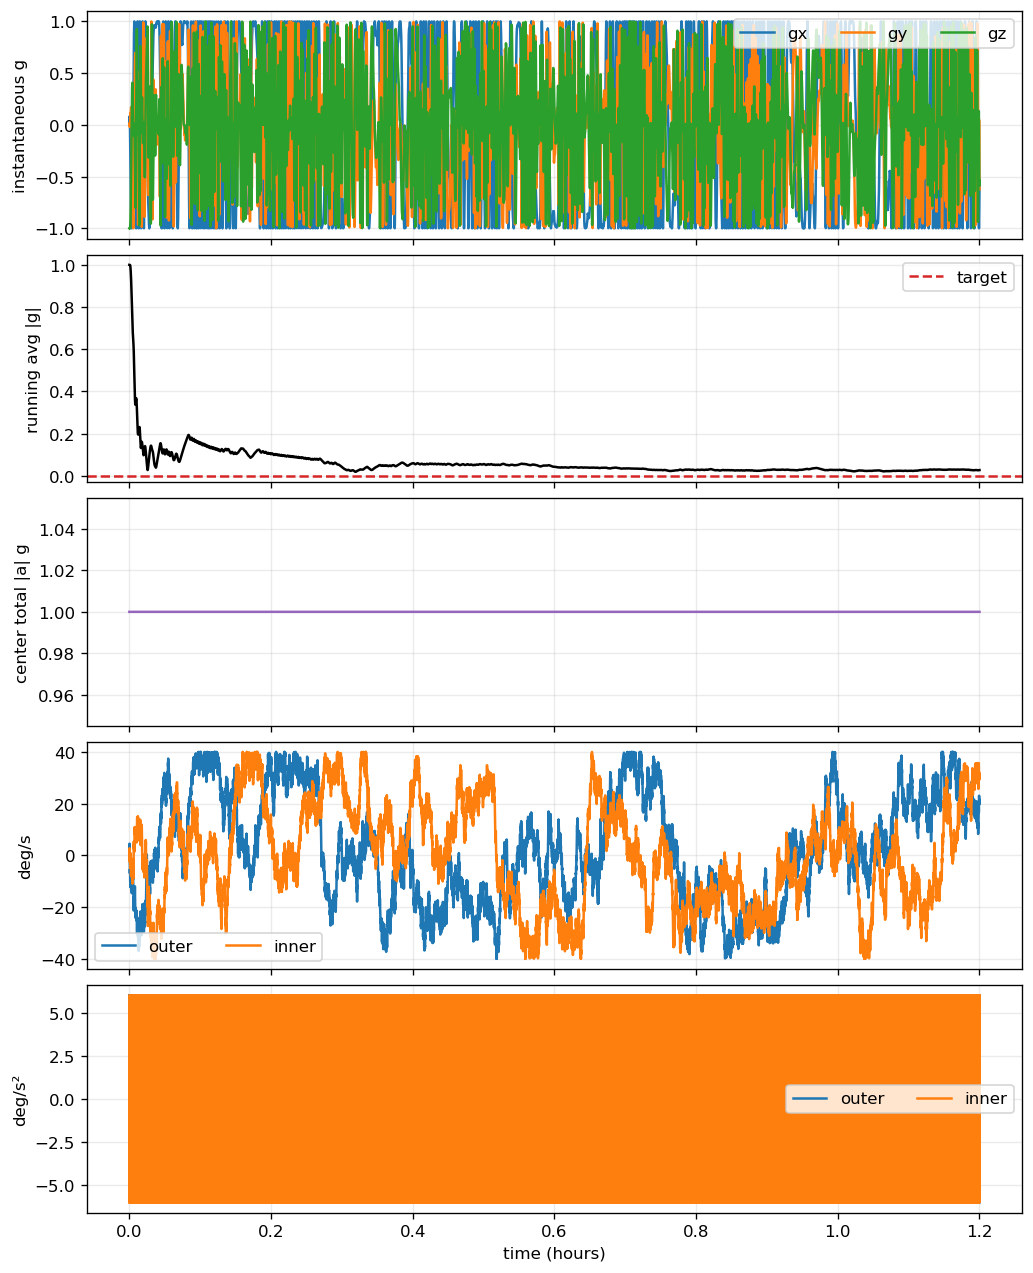

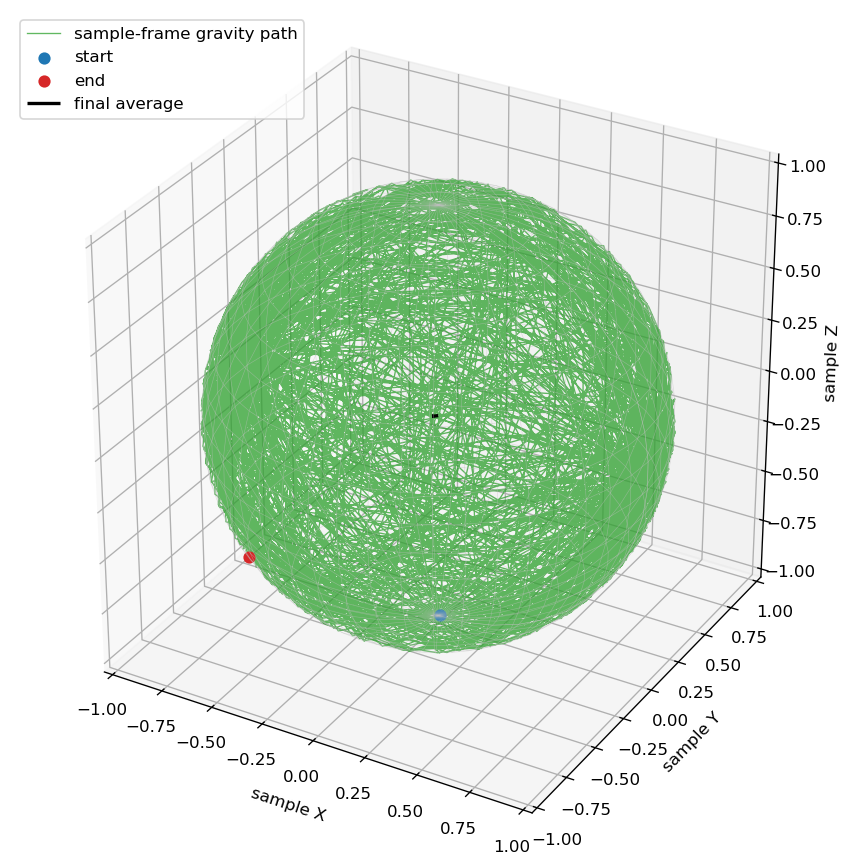

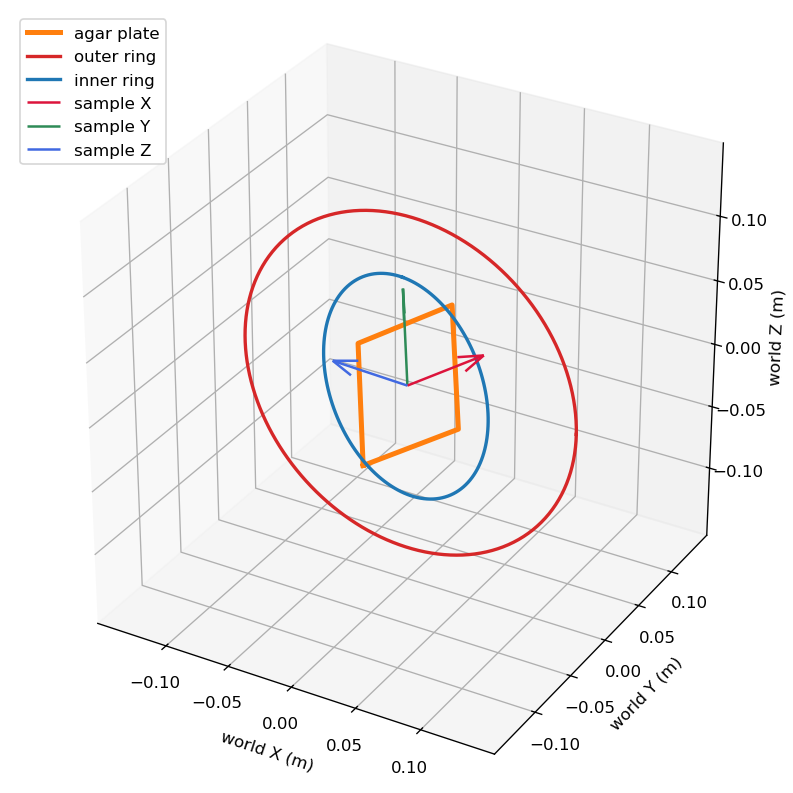

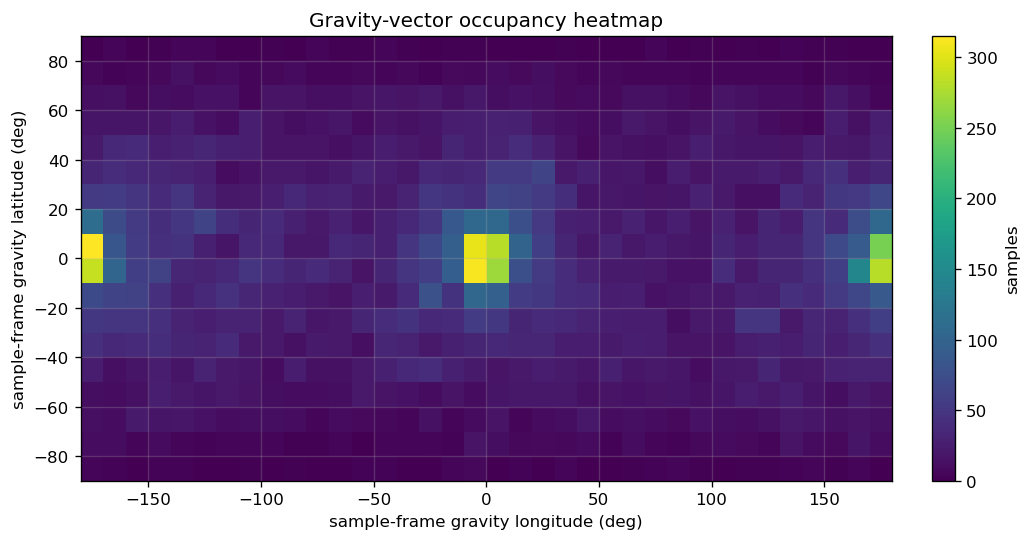

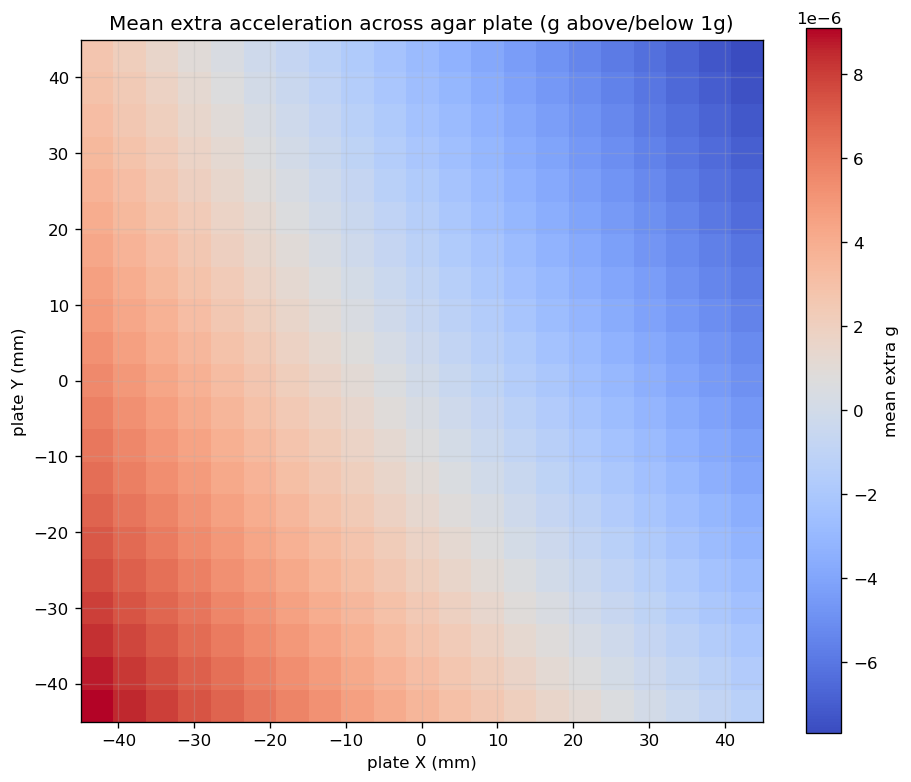

In [10]:
# Main figures for review.
fig1 = plot_time_series(df, cfg)
plt.show()
fig2 = plot_gravity_sphere(df, meta)
plt.show()
fig3 = plot_gimbal_3d(df, cfg)
plt.show()
fig4 = plot_orientation_heatmap(meta)
plt.show()
fig5 = plot_force_map(df, meta)
plt.show()

In [11]:
# Export data, figures, and builder-facing files.
out_dir = Path("rpm_notebook_outputs")
out_dir.mkdir(exist_ok=True)

df.to_csv(out_dir / "simulation_timeseries.csv", index=False)
points.to_csv(out_dir / "sample_point_analysis.csv", index=False)
validation.to_frame("value").to_csv(out_dir / "validation_metrics.csv")
window_validation.to_csv(out_dir / "moving_window_validation.csv", index=False)

schedule_path = export_command_schedule(df, cfg, out_dir / "rpm_command_schedule.csv")
pseudocode_path = export_pseudocode(cfg, out_dir / "rpm_controller_pseudocode.txt")
pdf_path = export_pdf_report(df, meta, point_summary, out_dir / "rpm_notebook_report.pdf")

print("Wrote:")
print(schedule_path)
print(pseudocode_path)
print(pdf_path)

Wrote:
/Users/kamdiehl/Desktop/PhD Project/PhD project CODE/RPM code/Random Positioning Machine Simulator/rpm_notebook_outputs/rpm_command_schedule.csv
/Users/kamdiehl/Desktop/PhD Project/PhD project CODE/RPM code/Random Positioning Machine Simulator/rpm_notebook_outputs/rpm_controller_pseudocode.txt
/Users/kamdiehl/Desktop/PhD Project/PhD project CODE/RPM code/Random Positioning Machine Simulator/rpm_notebook_outputs/rpm_notebook_report.pdf


## Optional Interactive Dashboard

If `ipywidgets` is available, the cell below creates a notebook control panel. It reruns the simulation when you press **Run simulation**. This is intentionally separate from the static cells above so the notebook can also run in simpler Python environments.

In [12]:
if WIDGETS_AVAILABLE:
    scenario = widgets.Dropdown(options=[("Microgravity", "micro"), ("Moon", "biased_moon"), ("Mars", "biased_mars"), ("Static", "static"), ("Random", "random")], value="micro", description="Scenario")
    duration = widgets.FloatLogSlider(value=0.01, base=10, min=-4, max=1, step=0.1, description="Days")
    target = widgets.FloatSlider(value=0.0, min=0, max=1, step=0.001, description="Target g")
    plate = widgets.FloatSlider(value=90, min=20, max=200, step=1, description="Plate mm")
    inner = widgets.FloatSlider(value=160, min=50, max=400, step=1, description="Inner mm")
    outer = widgets.FloatSlider(value=260, min=80, max=600, step=1, description="Outer mm")
    max_w = widgets.FloatSlider(value=40, min=1, max=40, step=1, description="Max deg/s")
    max_a = widgets.FloatSlider(value=6, min=0.5, max=40, step=0.5, description="Max deg/s²")
    run_button = widgets.Button(description="Run simulation", button_style="primary")
    out = widgets.Output()

    def on_run(_):
        with out:
            clear_output(wait=True)
            if scenario.value == "biased_moon":
                c = preset_config("moon")
            elif scenario.value == "biased_mars":
                c = preset_config("mars")
            else:
                c = RPMConfig(scenario=scenario.value)
            c = c.copy(duration_days=duration.value, target_g=target.value,
                       plate_side_mm=plate.value, inner_rotator_diameter_mm=inner.value,
                       outer_rotator_diameter_mm=outer.value,
                       max_angular_velocity_deg_s=max_w.value,
                       max_angular_acceleration_deg_s2=max_a.value)
            local_df, local_meta = run_experiment(c, seed=11, fast=True, progress=False)
            val, win = target_validation(local_df, local_meta)
            display(val.to_frame("value"))
            display(win)
            display(plot_time_series(local_df, c)); plt.show()
            display(plot_gravity_sphere(local_df, local_meta)); plt.show()

    run_button.on_click(on_run)
    display(widgets.VBox([
        widgets.HBox([scenario, duration, target]),
        widgets.HBox([plate, inner, outer]),
        widgets.HBox([max_w, max_a, run_button]),
        out,
    ]))
else:
    print("ipywidgets is not installed in this Python environment. The non-interactive cells above still work.")